# Module 9

## Machine learning using scikit-learn II

- Nested cross-validation for performance estimation
- XGBoost as a flexible and high-performing tree-based machine learning method
- Unsurpervised learning


In [13]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme() ## this sets some style parameters

# To check version of sklearn, run the following command in your terminal:
# python -c "import sklearn; print(sklearn.__version__)"


Dataset loading and merging: ``df_subj_FA``

In [14]:
df_MRI = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/regression_data/nodes.csv?raw=true')
df_subj = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/regression_data/subjects.csv?raw=true')

df_MRI["tractID"] = df_MRI["tractID"].replace(" ", "_", regex=True)

# Transform dataset
df_FA_HD_wide = df_MRI.pivot(index=["subjectID"], columns=["tractID", "nodeID"] , values="fa")
df_FA_HD_wide.columns = df_FA_HD_wide.columns.to_flat_index()
df_subj_FA_HD = pd.merge(df_subj, df_FA_HD_wide, on="subjectID")
df_subj_FA_HD = df_subj_FA_HD.drop(columns=['Unnamed: 0', 'subjectID'])

X_FA_HD = df_subj_FA_HD.drop(columns = ['Age', 'Gender', 'Handedness', 'IQ', 'IQ_Matrix', 'IQ_Vocab'])
y = df_subj_FA_HD['Age']

print(f"Final dataset shape: X: {X_FA_HD.shape}; y: {y.shape}")


Final dataset shape: X: (77, 2000); y: (77,)


### Nested cross-validation: Model evaluation without a prespecified test set

Main idea: Repeatedly consider different train/validation/test splits of the data.

- In the inner loop, models are fit on the training data and compared on the validation data to select the best hyperparameters.
- In the outer loop, the selected model is evaluated on the test data. Out of sample error is estimated by averaging these test-set scores across splits.

This approach gives a less biased estimate of out-of-sample performance because the test data in each outer split are not used for model tuning and allows you to use all the data without having to prespecified a test set.

In [15]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score


# Let's use ridge regression as our running model
model_HD_ridge = make_pipeline(
    SimpleImputer(strategy="median"),
    Ridge(max_iter=10000)
)

model_HD_ridge.named_steps

{'simpleimputer': SimpleImputer(strategy='median'),
 'ridge': Ridge(max_iter=10000)}

In [16]:
# Set up possible values of parameters to optimize over
param_grid = {"ridge__alpha": np.logspace(-4, 2, 50)}

# Two cross-validation objects!
inner_cv = KFold(n_splits=4, shuffle=True, random_state=0)
outer_cv = KFold(n_splits=4, shuffle=True, random_state=1)

# Nested CV with parameter optimization
clf = GridSearchCV(estimator=model_HD_ridge, param_grid=param_grid, cv=inner_cv)
nested_score = cross_val_score(clf, X=X_FA_HD, y=y, cv=outer_cv)
nested_scores = nested_score.mean()


In [17]:
print(f" Outer CV score: {nested_score.mean():2.2f} ({nested_score.std():2.2f})")

 Outer CV score: 0.21 (0.24)


In [18]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

# Refit on the full dataset for deployment / final use
final_search = GridSearchCV(
    estimator=model_HD_ridge,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="r2",
    refit=True
)

final_search.fit(X_FA_HD, y)

print("Best alpha on full data:", final_search.best_params_)

# This is the final trained model
final_model = final_search.best_estimator_

Best alpha on full data: {'ridge__alpha': np.float64(7.9060432109077015)}


### XGBoost

XGBoost is a **gradient boosting** method that builds a prediction function as a sum of many simple trees,

$$
\hat{y}_i = \sum_{m=1}^M f_m(x_i), \qquad f_m \in \mathcal{F},
$$

where each \(f_m\) is a decision tree. The trees are added sequentially: at step \(m\), the new tree is chosen to improve the current model by approximately minimizing an objective of the form

$$
\mathcal{L}^{(m)} = \sum_{i=1}^n l\big(y_i, \hat{y}_i^{(m-1)} + f_m(x_i)\big),
$$

where $l(\cdot,\cdot)$ is a loss function, such as squared error or logistic loss, and \(\Omega(f_m)\) is a regularization term that penalizes overly complex trees.

XGBoost is especially popular for structured or tabular data, and has often strong predictive performance (Swiss Army knife of ML).

In [ ]:
# conda install conda-forge::xgboosty (after activating your biost506 environment)
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Ridge works better when features are scaled
model_HD_xgb = make_pipeline(
    SimpleImputer(strategy="median"),
    xgb.XGBRegressor(
    n_estimators=100,       # number of trees (M)
    max_depth=2,            # depth of each tree (complexity)
    learning_rate=0.01,     # How much to downeight trees progressively
    subsample=0.8,          # Fraction of the training observations randomly sampled for each tree
    colsample_bytree=0.8,   # Fraction of features randomly sampled when constructing each tree
    random_state=42)
)


In [20]:
model_HD_xgb.named_steps


{'simpleimputer': SimpleImputer(strategy='median'),
 'xgbregressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)}

In [21]:
# Let's assess performance it with with nested cross-validation


# Set up possible values of parameters to optimize over
param_grid = {"xgbregressor__n_estimators": np.linspace(5, 300, 10).astype("int"),
              "xgbregressor__max_depth": [2],
              "xgbregressor__learning_rate": [0.01],
              }

inner_cv = KFold(n_splits=4, shuffle=True, random_state=0)
outer_cv = KFold(n_splits=4, shuffle=True, random_state=1)

# Nested CV with parameter optimization
clf = GridSearchCV(estimator=model_HD_xgb, param_grid=param_grid, cv=inner_cv)
nested_score = cross_val_score(clf, X=X_FA_HD, y=y, cv=outer_cv)


In [22]:
print(f" Outer CV score: {nested_score.mean():2.2f} ({nested_score.std():2.2f})")

 Outer CV score: 0.17 (0.18)


### Unsupervised learning

Scikit-learn also implements several unsupervised learning algorithms, where the goal is to discover patterns or structure in the data without using labeled outcomes.

Two common types of unsupervised learning are:
- Dimensionality reduction
- Clustering

Let's explore two of the most popular dimension reduction approaches!

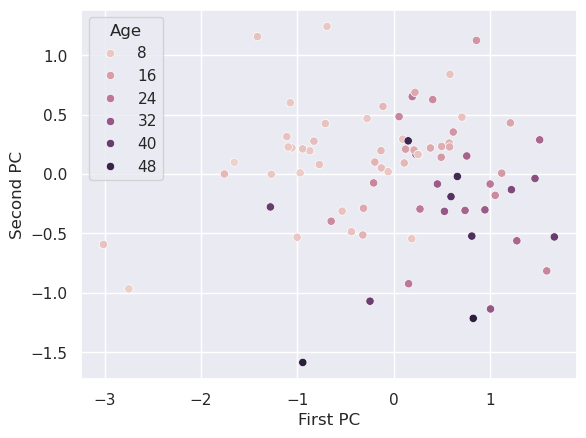

In [23]:
# Example PCA

from sklearn.decomposition import PCA  

X_FA_HD_nomiss = SimpleImputer(strategy="median").fit_transform(X_FA_HD)


model = PCA(n_components=2)            # Instantiate the model with hyperparameters
model.fit(X_FA_HD_nomiss)           # Fit to data. Notice y is not specified!
X_2D = model.transform(X_FA_HD_nomiss)        # Get transformed data

sns.scatterplot(x = X_2D[:,0], y = X_2D[:,1], hue = y)
plt.xlabel("First PC")
plt.ylabel("Second PC");

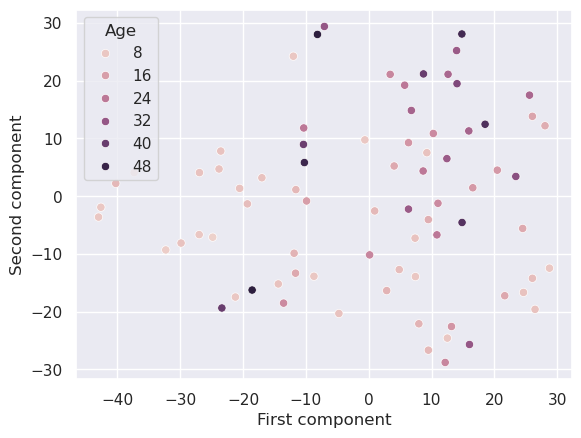

In [24]:
# Example TSNE

from sklearn.manifold import TSNE
model_tsne = make_pipeline(
    PCA(n_components=50),
    TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3)
    )

X_2D_manifold = model_tsne.fit_transform(X_FA_HD_nomiss)

sns.scatterplot(x = X_2D_manifold[:,0], y = X_2D_manifold[:,1], hue = y)
plt.xlabel("First component")
plt.ylabel("Second component");

Unsupervised and supervised approaches can also be combined. For example, one may first perform dimensionality reduction and then use the resulting features in a regression or classification model. We will explore this further in the next homework.

Scikit-learn makes this particularly simple!